In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [6]:
f = h5py.File("data/h2_results.hdf5", "r")
h = f["h"][:, :]
s = f["s"][:, :]
h_u = f["h_u"][:, :]
s_u = f["s_u"][:, :]
energies = f["energies"][:]
energies_u = f["energies_u"][:]
num_kept = f["num_kept"][:]
num_kept_u = f["num_kept_u"][:]
hf_energy = f["hf_energy"][()]
fci_energy = f["fci_energy"][()]
dmrg_energy = f["dmrg_energy"][()]
bond_sizes = f["bond_sizes"][()]
f.close()

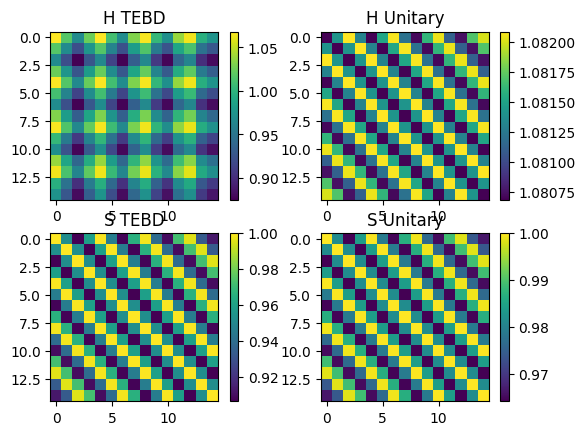

In [3]:
fig, ax = plt.subplots(2, 2)
im1 = ax[0, 0].imshow(np.abs(h))
ax[0, 0].set_title("H TEBD")
im2 = ax[1, 0].imshow(np.abs(s))
ax[1, 0].set_title("S TEBD")
im3 = ax[0, 1].imshow(np.abs(h_u))
ax[0, 1].set_title("H Unitary")
im4 = ax[1, 1].imshow(np.abs(s_u))
ax[1, 1].set_title("S Unitary")
fig.colorbar(im1)
fig.colorbar(im2)
fig.colorbar(im3)
fig.colorbar(im4)

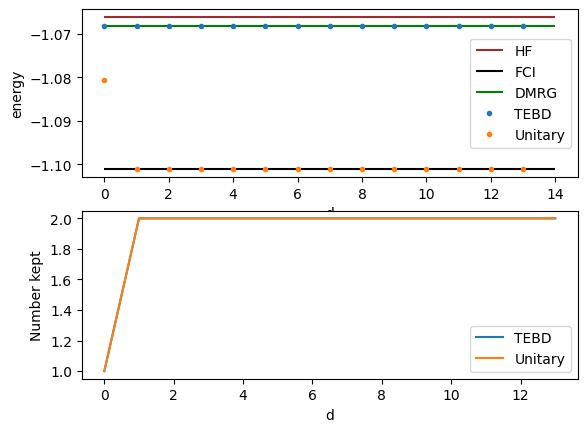

In [4]:
fig2, ax2 = plt.subplots(2, 1)
ax2[0].hlines(hf_energy, 0., len(energies), colors=["brown"], label="HF")
ax2[0].hlines(fci_energy, 0., len(energies), colors=["black"], label="FCI")
ax2[0].hlines(dmrg_energy, 0., len(energies), colors=["green"], label="DMRG")
ax2[0].plot(energies, '.', label="TEBD")
ax2[0].plot(energies_u, '.', label="Unitary")
ax2[0].set_ylabel("energy")
ax2[0].set_xlabel("d")
ax2[0].legend()

ax2[1].plot(num_kept, label="TEBD")
ax2[1].plot(num_kept_u, label="Unitary")
ax2[1].set_xlabel("d")
ax2[1].set_ylabel("Number kept")
ax2[1].legend()

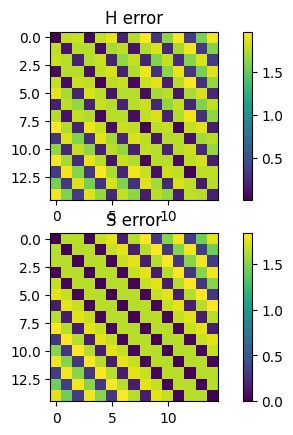

In [5]:
h_err = np.abs(h - h_u)
s_err = np.abs(s - s_u)

fig3, ax3 = plt.subplots(2, 1)
im1 = ax3[0].imshow(h_err)
ax3[0].set_title("H error")
im2 = ax3[1].imshow(s_err)
ax3[1].set_title("S error")
fig3.colorbar(im1)
fig3.colorbar(im2)

(15, 3)


/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_3640/3353380543.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


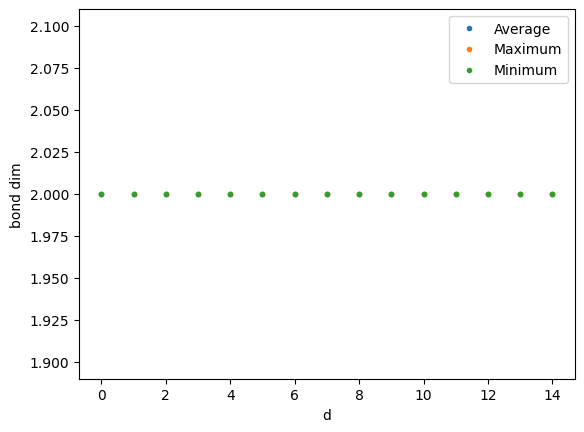

In [12]:
print(bond_sizes.shape)
bond_size_avg = np.average(bond_sizes, axis=1)
bond_size_max = np.max(bond_sizes, axis=1)
bond_size_min = np.min(bond_sizes, axis=1)
fig4, ax4 = plt.subplots()
ax4.legend()
ax4.plot(bond_size_avg, '.', label="Average")
ax4.plot(bond_size_max, '.', label="Maximum")
ax4.plot(bond_size_min, '.', label="Minimum")
ax4.set_xlabel("d")
ax4.set_ylabel("bond dim")
ax4.legend()